# Gerry bioactivity → AnnData

Thirty structurally related compounds at six doses in U2OS ([`cpg0005`](https://broadinstitute.github.io/cellpainting-gallery/)). Published as one flat CSV whose only non-feature column is an opaque `well_profile_id`; there is no plate, well or treatment annotation to join against, so the embedding can be built but nothing can be tested against it.

One observation is a well, one variable is a CellProfiler feature.
Well-level profiles only, no images:

```bash
aws s3 cp --no-sign-request --recursive --exclude "*" --include "*.csv" \
  s3://cellpainting-gallery/cpg0005-gerry-bioactivity/broad/workspace/profiles/ .
```

In [1]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import scanpy as sc

import cell_painting_io as cpio

PROFILES = Path("~/data/cpg0005-gerry-bioactivity/profiles").expanduser()

In [2]:
files = sorted(PROFILES.glob("*.csv"))
print(f"{len(files)} plates")

1 plates


In [3]:
adata = cpio.read_profiles(files, metadata_columns=["well_profile_id"], index_columns=["well_profile_id"])
adata

AnnData object with n_obs × n_vars = 4608 × 1474
    obs: 'well_profile_id'
    layers: None (.X)

In [4]:
cpio.annotate_features(adata.var)
adata = cpio.drop_incomplete_features(adata)
adata = cpio.drop_extreme_features(adata)
adata = cpio.drop_constant_features(adata)


def present(columns):
    return [c for c in columns if c in adata.obs.columns and adata.obs[c].nunique() > 1]


adata.var

,compartment,family,channel,channel_2,n_channels
feature,,,,,
Cell_AreaShape_Area,cell,areashape,NaN,NaN,0
Cell_AreaShape_Center_X,cell,areashape,NaN,NaN,0
Cell_AreaShape_Center_Y,cell,areashape,NaN,NaN,0
Cell_AreaShape_Compactness,cell,areashape,NaN,NaN,0
Cell_AreaShape_Eccentricity,cell,areashape,NaN,NaN,0
...,...,...,...,...,...
Nucleus_Texture_Variance_Mito_3_0,nucleus,texture,mito,NaN,1
Nucleus_Texture_Variance_Mito_5_0,nucleus,texture,mito,NaN,1
Nucleus_Texture_Variance_RNA_10_0,nucleus,texture,rna,NaN,1


## Sanity checks

In [5]:
print(f"{adata.n_obs:,} wells x {adata.n_vars:,} features")
print(f"non-finite: {int((~np.isfinite(adata.X)).sum())} | max|x|: {np.abs(adata.X).max():.1f}")
for column in present([]):
    print(f"\n{column}:")
    print(adata.obs[column].value_counts(dropna=False).head(6).to_string())

4,608 wells x 1,467 features
non-finite: 0 | max|x|: 5001.5


In [6]:
adata.write_h5ad(PROFILES.parent / "gerry.h5ad")

## UMAP

The profiles are already normalized, so they enter PCA unscaled.

In [7]:
sc.pp.pca(adata, n_comps=min(50, adata.n_vars - 1))
sc.pp.neighbors(adata, n_neighbors=15)
sc.tl.umap(adata)

/home/lheumos/miniforge3/envs/cell-painting-io/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


How often do neighbouring wells share a label, against the rate expected if labels were shuffled?
Above 1 means the covariate explains part of the embedding.

In [8]:
cpio.neighbour_enrichment(adata, present([]))

,observed,baseline,ratio
covariate,,,


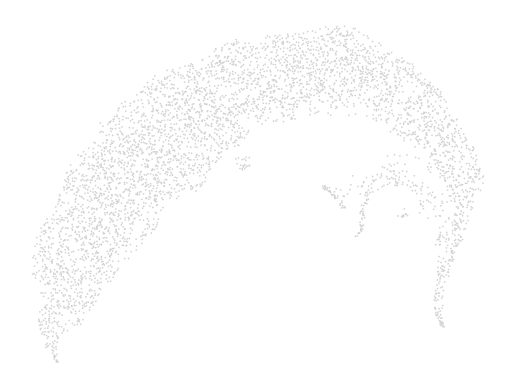

In [9]:
colours = present([])[:3] or None
sc.pl.umap(adata, color=colours, ncols=3, frameon=False, size=6)